# Encoder-Only (Pointwise MLP) — Hyperparameter Sweep

Performs a **Hydra grid sweep** over encoder-only regularisation parameters
using SLURM for parallel training.

**Supports two data sources** (set `DATA_SOURCE` in Section 1):
- `"dysts"` — synthetic trajectories from dynamical systems (e.g. Lorenz)
- `"wmtask"` — hidden-state trajectories from a trained working memory RNN

**Key difference from the SSM/Transformer sweep:** The encoder is a **pointwise
MLP** — it applies the same MLP independently at each timestep with **no
temporal context**. All temporal information comes from the delay embedding
in the input. This avoids the double-smoothing problem where an SSM's
recurrent state integration compounds with the delay embedding's implicit
temporal averaging, compressing the Lyapunov spectrum toward zero.

**Pipeline:**
1. Set hyperparameters in clearly labelled cells (Sections 1–2)
2. Build Hydra config (single source of truth for local + sweep)
3. Generate data locally for post-hoc diagnostics
4. Check W&B for already-completed runs
5. Launch Hydra `--multirun` sweep via SLURM (one job per parameter combination)
6. Collect results and visualise

> **Wait for all SLURM jobs to finish** before running Section 7.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import itertools
import subprocess
import sys, os

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb
from hydra.utils import instantiate
from omegaconf import OmegaConf

from JacobianODE.jacobians.core import seed_everything
from JacobianODE.jacobians.data import make_trajectories, postprocess_data, create_dataloaders
from JacobianODE.jacobians.training import train_model
from JacobianODE.encoder_only.config import load_encoder_config

torch.set_float32_matmul_precision('high')
print(f'PyTorch {torch.__version__}  |  GPUs: {torch.cuda.device_count()}')

PyTorch 2.10.0+cu128  |  GPUs: 1


## 1. Hyperparameters

In [3]:
# ----------------------------------------------------------------
# Paths and W&B settings
# ----------------------------------------------------------------
SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/encoder_runs"
WANDB_ENTITY = "JacobianODE"

In [51]:
# ----------------------------------------------------------------
# Data source: "dysts" or "wmtask"
# ----------------------------------------------------------------
DATA_SOURCE = "wmtask"   # <-- change to "wmtask" for WM task RNN data
# DATA_SOURCE = "dysts"

# ----------------------------------------------------------------
# dysts-specific hyperparameters (ignored when DATA_SOURCE="wmtask")
# ----------------------------------------------------------------
NUM_ICS = 32
N_PERIODS = 12
PTS_PER_PERIOD = 100

# ----------------------------------------------------------------
# wmtask-specific hyperparameters (ignored when DATA_SOURCE="dysts")
# ----------------------------------------------------------------
WMTASK_PROJECT = "WMSelectionTask__cue_time_0.1__response_time_0.25__enforce_fixation_False"
WMTASK_NAME = "BiologicalRNN__cue_time_0.1__learning_rate_0.0005__max_epochs_42__N1_64__N2_64__tau_0.05__dt_0.02__eig_lower_bound_0.1__init_mode_random"
WMTASK_MODEL_TO_LOAD = "final"
WMTASK_DATALOADER = "all"
WMTASK_TRAJ_WINDOW = "delay2"   # 'delay2' or 'full'
WMTASK_DIM = 128                # N1 + N2 = 64 + 64

# ----------------------------------------------------------------
# Shared data hyperparameters
# ----------------------------------------------------------------

OBS_NOISE = 0.01
NORMALIZE = True

# Partial observation (delay embedding)
# The MLP encoder has NO temporal context — all history comes from the
# delay embedding.  We use a generous embedding (43 delays, spacing=1)
# to ensure Takens-style reconstruction of the attractor geometry.
# OBSERVED_INDICES = [0]
# N_DELAYS = 43
# # DELAY_SPACING = 1
# N_DELAYS = 5
# DELAY_SPACING = 10

# OBSERVED_INDICES = [0, 1, 2]
# N_DELAYS = 1
# DELAY_SPACING = 1
if DATA_SOURCE == "dysts":
    OBSERVED_INDICES = [0]
    N_DELAYS = 25
    DELAY_SPACING = 1
    SEQ_LENGTH = 100
else:
    # wmtask: observe all hidden dims by default; set to a list for partial obs
    OBSERVED_INDICES = 'all'
    N_DELAYS = 1
    DELAY_SPACING = 1
    SEQ_LENGTH = 49

In [52]:
# ----------------------------------------------------------------
# Encoder / architecture hyperparameters — Pointwise MLP
# ----------------------------------------------------------------
MODEL = 'mlp'   # pointwise MLP (no temporal context)

if DATA_SOURCE == "dysts":
    # N_LATENT = 3
    N_LATENT = 6
else:
    N_LATENT = 128

# MLP parameters
MLP_HIDDEN_DIM = 256
MLP_N_LAYERS   = 3
MLP_DROPOUT    = 0.1

# Decoder head (shared across architectures)
USE_SAME_STATE_DECODER = True
USE_NEXT_STATE_DECODER = True
DECODER_HIDDEN_DIM    = 128
DECODER_N_LAYERS      = 2
NEXT_STATE_BURN_IN    = 0

# Multi-step ahead prediction:
# K_STEPS_AHEAD=k means the next-state decoder jointly predicts [x_{t+1}, ..., x_{t+k}],
# which forces the latent to encode the full dynamical state rather than collapsing.
K_STEPS_AHEAD = 10

# Raw observation dimension for next-state targets.
# When delay embedding is active (N_DELAYS > 1), set this to len(OBSERVED_INDICES)
# so that targets are un-embedded observations: [x_{t+1}, ..., x_{t+k}] without redundancy.
if OBSERVED_INDICES == 'all':
    N_OBS_PRED = WMTASK_DIM  # full hidden state
else:
    N_OBS_PRED = len(OBSERVED_INDICES)  # = raw obs dim, independent of N_DELAYS

In [53]:
if DATA_SOURCE == "dysts":
    _obs_label = ''.join(str(i) for i in OBSERVED_INDICES)
    WANDB_PROJECT = f"Lorenz_IND{_obs_label}_N{N_DELAYS}_D{DELAY_SPACING}_Norm{NORMALIZE}_L{N_LATENT}__EncoderOnly"
elif DATA_SOURCE == "wmtask":
    if OBSERVED_INDICES == 'all':
        _obs_label = 'all'
    else:
        _obs_label = ''.join(str(i) for i in OBSERVED_INDICES)
    WANDB_PROJECT = f"WMTask_IND{_obs_label}_N{N_DELAYS}_D{DELAY_SPACING}_Norm{NORMALIZE}_L{N_LATENT}__EncoderOnly"

WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

# Optional: W&B group to separate different experiments within the same project.
# Set to a string (e.g. "fnn_sweep_2026", "sweep_v2") to group this sweep's runs.
# When set, sweep jobs log to this group and post-hoc evaluation filters by it.
# Set to None to log runs without a group.
# WANDB_GROUP = None  # e.g. "fnn_sweep_2026-03" or "sweep_v2"
WANDB_GROUP = f"MLP_L{N_LATENT}"

In [54]:
# ----------------------------------------------------------------
# Training hyperparameters
# ----------------------------------------------------------------
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
MAX_EPOCHS = 150
LIMIT_TRAIN_BATCHES = 200
EARLY_STOPPING_PATIENCE = 2
PERCENT_THRESH = 0.01

FNN_USE_PCA = True
FNN_N_SAMPLES = 1024
FNN_NORMALIZE = True
FNN_ELEMENTWISE_REGULARIZATION = True


In [55]:
# ----------------------------------------------------------------
# Sweep parameters — Hydra --multirun will grid over all combinations
# ----------------------------------------------------------------
# Each key is a Hydra override path; each value is a list of values to sweep.
# The sweep command will be built automatically from this dict.
SWEEP_PARAMS = {
    "training.lightning.fnn_weight": [0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10],
    "training.lightning.amplification_weight": [0.0],
    "training.lightning.decov_weight": [0.0],
}

# Count total combinations
n_combos = 1
for vals in SWEEP_PARAMS.values():
    n_combos *= len(vals)
print(f"Sweep grid: {n_combos} total combinations")

Sweep grid: 8 total combinations


## 2. Build Base Config

Build the Hydra overrides list — this is the **single source of truth** used both
for local data generation and as the template for the sweep command.

In [56]:
# Format list-valued overrides without spaces so they double as valid Hydra CLI args
if OBSERVED_INDICES == 'all':
    _obs_idx_str = 'all'
else:
    _obs_idx_str = str(list(OBSERVED_INDICES)).replace(' ', '')

overrides = [
    # --- Model ---
    f"model={MODEL}",
    f"++model.encoder.n_latent={N_LATENT}",
    f"++model.use_same_state_decoder={str(USE_SAME_STATE_DECODER).lower()}",
    f"++model.use_next_state_decoder={str(USE_NEXT_STATE_DECODER).lower()}",
    f"++model.decoder_hidden_dim={DECODER_HIDDEN_DIM}",
    f"++model.decoder_n_layers={DECODER_N_LAYERS}",
    f"++model.next_state_burn_in={NEXT_STATE_BURN_IN}",
    f"++model.k_steps_ahead={K_STEPS_AHEAD}",
    f"++model.n_obs_pred={N_OBS_PRED}",
]

# Architecture-specific encoder overrides
if MODEL == 'mlp':
    overrides.extend([
        f"++model.encoder.hidden_dim={MLP_HIDDEN_DIM}",
        f"++model.encoder.n_layers={MLP_N_LAYERS}",
        f"++model.encoder.dropout={MLP_DROPOUT}",
    ])
elif MODEL == 'ssm':
    overrides.extend([
        f"++model.encoder.d_model={SSM_D_MODEL}",
        f"++model.encoder.d_state={SSM_D_STATE}",
        f"++model.encoder.n_layers={SSM_N_LAYERS}",
        f"++model.encoder.r_min={SSM_R_MIN}",
        f"++model.encoder.r_max={SSM_R_MAX}",
        f"++model.encoder.ffn_expand={SSM_FFN_EXPAND}",
        f"++model.encoder.dropout={SSM_DROPOUT}",
    ])
elif MODEL == 'transformer':
    overrides.extend([
        f"++model.encoder.d_model={TRANSFORMER_D_MODEL}",
        f"++model.encoder.n_heads={TRANSFORMER_N_HEADS}",
        f"++model.encoder.n_layers={TRANSFORMER_N_LAYERS}",
        f"++model.encoder.dim_feedforward={TRANSFORMER_DIM_FEEDFORWARD}",
        f"++model.encoder.dropout={TRANSFORMER_DROPOUT}",
    ])
elif MODEL == 'tcn':
    overrides.extend([
        f"++model.encoder.n_channels={TCN_N_CHANNELS}",
        f"++model.encoder.kernel_size={TCN_KERNEL_SIZE}",
        f"++model.encoder.n_layers={TCN_N_LAYERS}",
        f"++model.encoder.dropout={TCN_DROPOUT}",
    ])

overrides.extend([
    # --- Training ---
    f"++training.batch_size={BATCH_SIZE}",
    f"++training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"++training.lightning.fnn_use_pca={FNN_USE_PCA}",
    f"++training.lightning.fnn_n_samples={FNN_N_SAMPLES}",
    f"++training.lightning.fnn_normalize={FNN_NORMALIZE}",
    f"++training.lightning.fnn_elementwise_regularization={FNN_ELEMENTWISE_REGULARIZATION}",
    f"++training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"++training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"++training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
    f"++training.early_stopping.percent_thresh={PERCENT_THRESH}",

    # --- Shared data ---
    f"++data.train_test_params.seq_length={SEQ_LENGTH}",
    f"++data.postprocessing.obs_noise={OBS_NOISE}",
    f"++data.postprocessing.normalize={NORMALIZE}",

    # --- Partial observation / delay embedding ---
    f"++data.train_test_params.delay_embedding_params.observed_indices={_obs_idx_str}",
    f"++data.train_test_params.delay_embedding_params.n_delays={N_DELAYS}",
    f"++data.train_test_params.delay_embedding_params.delay_spacing={DELAY_SPACING}",

    # --- Save directory ---
    f"++training.logger.save_dir={SAVE_DIR}",
])

# Data-source-specific overrides
if DATA_SOURCE == "dysts":
    overrides.extend([
        f"++data.trajectory_params.num_ics={NUM_ICS}",
        f"++data.trajectory_params.n_periods={N_PERIODS}",
        f"++data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    ])
elif DATA_SOURCE == "wmtask":
    overrides.extend([
        "data=wmtask",
        f"++data.dataset_loader.project={WMTASK_PROJECT}",
        f"++data.dataset_loader.name={WMTASK_NAME}",
        f"++data.dataset_loader.model_to_load={WMTASK_MODEL_TO_LOAD}",
        f"++data.dataset_loader.dataloader_to_use={WMTASK_DATALOADER}",
        f"++data.dataset_loader.traj_window={WMTASK_TRAJ_WINDOW}",
        f"++data.flow.dim={WMTASK_DIM}",
    ])

cfg = load_encoder_config(overrides=overrides)

# Auto-generate project name if not set
if WANDB_PROJECT is None:
    if DATA_SOURCE == "dysts":
        data_cls = cfg.data.flow._target_.split('.')[-1]
    else:
        data_cls = cfg.data.get('name', DATA_SOURCE)
    WANDB_PROJECT = f"{data_cls}__EncoderOnly"
    WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

print(f"W&B project: {WANDB_PROJECT_PATH}")
encoder_cls = cfg.model.encoder._target_.split('.')[-1]
print(f"Encoder: {encoder_cls}")
if hasattr(cfg.model.encoder, 'hidden_dim'):
    print(f"  n_latent={cfg.model.encoder.n_latent}, hidden_dim={cfg.model.encoder.hidden_dim}, n_layers={cfg.model.encoder.n_layers}")
else:
    print(f"  n_latent={cfg.model.encoder.n_latent}, d_model={cfg.model.encoder.d_model}")
if OBSERVED_INDICES == 'all':
    _n_raw_obs = WMTASK_DIM
else:
    _n_raw_obs = len(OBSERVED_INDICES)
print(f"  Input dim (delay embedded): N_DELAYS={N_DELAYS} x n_raw_obs={_n_raw_obs} = {N_DELAYS * _n_raw_obs}")
print(OmegaConf.to_yaml(cfg))

W&B project: JacobianODE/WMTask_INDall_N1_D1_NormTrue_L128__EncoderOnly
Encoder: MLPSequenceEncoder
  n_latent=128, hidden_dim=256, n_layers=3
  Input dim (delay embedded): N_DELAYS=1 x n_raw_obs=128 = 128
wandb_entity: JacobianODE
wandb_project: null
wandb_group: null
training:
  batch_size: 32
  run_number: 0
  lightning:
    _target_: JacobianODE.encoder_only.model.LitEncoderDecoder
    optimizer: AdamW
    optimizer_kwargs:
      lr: 0.0001
      weight_decay: 0.0001
    use_scheduler: true
    min_lr: 1.0e-06
    lr_scheduler_patience: 10
    lr_scheduler_factor: 0.5
    gradient_clip_val: 1.0
    gradient_clip_algorithm: norm
    same_state_weight: 1.0
    next_state_weight: 1.0
    fnn_weight: 0.0
    fnn_normalize: true
    fnn_elementwise_regularization: true
    fnn_use_pca: true
    fnn_n_samples: 1024
    amplification_weight: 0.0
    decov_weight: 0.0
    amplification_n_neighbors: 10
    amplification_max_T: 5
  logger:
    _target_: pytorch_lightning.loggers.WandbLogger


## 3. Generate Data

Generate trajectories once locally. The same data pipeline runs inside each
SLURM job (deterministic via fixed seed), but we also need it here for
post-hoc diagnostics.

In [57]:
seed_everything(cfg.data.flow.random_state)
eq, sol, dt = make_trajectories(cfg)
print(f"Full trajectory shape: {sol['values'].shape}")
print(f"Time step dt = {dt:.4f}")

loaded wmtask RNN model checkpoint 41
Full trajectory shape: (4096, 49, 128)
Time step dt = 0.0200


In [58]:
result = postprocess_data(cfg, sol['values'])
values = result.values
cfg.data.postprocessing.noise_scale_factor = result.noise_scale_factor
cfg.data.postprocessing.mu = result.mu
cfg.data.postprocessing.sigma = result.sigma

train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values)
n_obs = trajs['train_trajs'].sequence.shape[-1]

print(f"n_obs = {n_obs}")
print(f"Train: {len(train_dl.dataset)} sequences")
print(f"Val:   {len(val_dl.dataset)} sequences")

n_obs = 128
Train: 2867 sequences
Val:   820 sequences


## 4. Check W&B for Completed Runs

Query W&B for runs that match the current sweep parameter combinations.
Only the remaining (not-yet-completed) combinations will be launched.

In [59]:
def _get_sweep_param_from_run(run, key):
    """Extract a sweep parameter value from a W&B run config.

    Keys are dot-separated Hydra paths like 'training.lightning.fnn_weight'.
    """
    parts = key.split('.')
    val = run.config
    for p in parts:
        if not isinstance(val, dict) or p not in val:
            return None
        val = val[p]
    return val


def _combo_matches_run(combo, run):
    """Check if a parameter combination matches a finished W&B run."""
    for key, target_val in combo.items():
        run_val = _get_sweep_param_from_run(run, key)
        if run_val is None:
            return False
        # Handle bool vs str comparisons
        if isinstance(target_val, bool):
            if bool(run_val) != target_val:
                return False
        elif isinstance(target_val, (int, float)):
            if abs(float(run_val) - float(target_val)) > 1e-10:
                return False
        else:
            if str(run_val) != str(target_val):
                return False
    return True


# Build all parameter combinations
sweep_keys = list(SWEEP_PARAMS.keys())
sweep_value_lists = [SWEEP_PARAMS[k] for k in sweep_keys]
all_combos = [
    dict(zip(sweep_keys, vals))
    for vals in itertools.product(*sweep_value_lists)
]

# Query W&B
api = wandb.Api()
try:
    run_filters = {"group": WANDB_GROUP} if WANDB_GROUP else None
    existing_runs = api.runs(WANDB_PROJECT_PATH, filters=run_filters)
    msg = f"Found {len(existing_runs)} total runs in {WANDB_PROJECT_PATH}"
    if WANDB_GROUP:
        msg += f" (group={WANDB_GROUP})"
    print(msg)
except Exception as e:
    print(f"Could not query project (may not exist yet): {e}")
    existing_runs = []

finished_runs = [r for r in existing_runs if r.state == 'finished']

already_done = []
remaining_combos = []
for combo in all_combos:
    if any(_combo_matches_run(combo, r) for r in finished_runs):
        already_done.append(combo)
    else:
        remaining_combos.append(combo)

print(f"\nAlready completed: {len(already_done)} / {len(all_combos)}")
print(f"Remaining to run:  {len(remaining_combos)}")

Found 6 total runs in JacobianODE/WMTask_INDall_N1_D1_NormTrue_L128__EncoderOnly (group=MLP_L128)

Already completed: 6 / 8
Remaining to run:  2


## 5. Launch Hydra Grid Sweep

Uses Hydra `--multirun` with the SLURM launcher to submit one job per
parameter combination. The `overrides` list from Section 2 is the
**single source of truth** — the sweep command simply appends the swept
parameters (comma-separated) and W&B/SLURM settings.

> **Wait for all SLURM jobs to finish** before proceeding to Section 7.

In [60]:
# ----------------------------------------------------------------
# Build the Hydra --multirun sweep command
# ----------------------------------------------------------------
ENTRY_POINT = "python -m JacobianODE.encoder_only.run_encoder"

if remaining_combos:
    n_remaining = len(remaining_combos)
    use_subset_sweep = n_remaining < n_combos

    wandb_overrides = [
        f"wandb_entity={WANDB_ENTITY}",
        f"wandb_project={WANDB_PROJECT}",
        "slurm=default",
    ]
    if WANDB_GROUP:
        wandb_overrides.append(f"wandb_group={WANDB_GROUP}")

    if use_subset_sweep:
        # One command per remaining combo — only run the missing combinations
        sweep_cmds = []
        for combo in remaining_combos:
            combo_overrides = [
                f"++{key}={str(val).lower() if isinstance(val, bool) else val}"
                for key, val in combo.items()
            ]
            sweep_overrides = overrides.copy() + combo_overrides + wandb_overrides
            sweep_cmds.append(f"{ENTRY_POINT} --multirun " + " ".join(sweep_overrides))
        print(f"Sweep command ({n_remaining} job(s), subset):")
        for i, cmd in enumerate(sweep_cmds):
            print(f"  [{i+1}] {cmd[:120]}...")
    else:
        # Full grid: Hydra --multirun creates the full grid from comma-separated values
        sweep_overrides = overrides.copy()
        for key, vals in SWEEP_PARAMS.items():
            val_str = ",".join(
                str(v).lower() if isinstance(v, bool) else str(v)
                for v in vals
            )
            sweep_overrides.append(f"++{key}={val_str}")
        sweep_overrides += wandb_overrides
        sweep_cmd = f"{ENTRY_POINT} --multirun " + " ".join(sweep_overrides)
        sweep_cmds = [sweep_cmd]
        print(f"Sweep command ({n_combos} jobs):")
        print(sweep_cmd)

if not remaining_combos:
    sweep_cmd = None
    sweep_cmds = []
    print("No sweep to launch — all runs already completed.")

Sweep command (2 job(s), subset):
  [1] python -m JacobianODE.encoder_only.run_encoder --multirun model=mlp ++model.encoder.n_latent=128 ++model.use_same_state_...
  [2] python -m JacobianODE.encoder_only.run_encoder --multirun model=mlp ++model.encoder.n_latent=128 ++model.use_same_state_...


In [61]:
# Launch the sweep (submits SLURM jobs).
if sweep_cmds:
    if len(sweep_cmds) > 1:
        print(f"Starting {len(sweep_cmds)} commands in parallel...")
    procs = [subprocess.Popen(cmd, shell=True) for cmd in sweep_cmds]
    for i, p in enumerate(procs):
        p.wait()
        if p.returncode != 0 and len(procs) > 1:
            print(f"Command {i + 1}/{len(procs)} exited with code {p.returncode}")
    print("Sweep complete.")
else:
    print("No sweep to launch — all runs already completed.")

Starting 2 commands in parallel...
Sweep output dir : multirun/2026-03-13/15-11-23-674031
Sweep output dir : multirun/2026-03-13/15-11-23-711871
[2026-03-13 15:11:23,790][HYDRA] Submitit 'slurm' sweep output dir : multirun/2026-03-13/15-11-23-674031
[2026-03-13 15:11:23,792][HYDRA] 	#0 : model=mlp ++model.encoder.n_latent=128 ++model.use_same_state_decoder=True ++model.use_next_state_decoder=True ++model.decoder_hidden_dim=128 ++model.decoder_n_layers=2 ++model.next_state_burn_in=0 ++model.k_steps_ahead=10 ++model.n_obs_pred=128 ++model.encoder.hidden_dim=256 ++model.encoder.n_layers=3 ++model.encoder.dropout=0.1 ++training.batch_size=32 ++training.lightning.optimizer_kwargs.lr=0.0001 ++training.lightning.fnn_use_pca=True ++training.lightning.fnn_n_samples=1024 ++training.lightning.fnn_normalize=True ++training.lightning.fnn_elementwise_regularization=True ++training.trainer_params.max_epochs=150 ++training.trainer_params.limit_train_batches=200 ++training.early_stopping.early_stopping

## 6. Collect W&B Runs

After all jobs finish, re-query W&B to verify all runs completed successfully.
Crashed/failed runs are flagged.

In [62]:
api = wandb.Api()
run_filters = {"group": WANDB_GROUP} if WANDB_GROUP else None
all_runs = api.runs(WANDB_PROJECT_PATH, filters=run_filters)
msg = f"Found {len(all_runs)} total runs in {WANDB_PROJECT_PATH}"
if WANDB_GROUP:
    msg += f" (group={WANDB_GROUP})"
print(msg)

# Flag crashed/failed runs
for run in all_runs:
    if run.state in ('crashed', 'failed'):
        print(f"  CRASHED/FAILED: {run.id} ({run.name}) — state={run.state}")

# Check completeness
finished_runs = [r for r in all_runs if r.state == 'finished']
completed_combos = []
missing_combos = []
for combo in all_combos:
    if any(_combo_matches_run(combo, r) for r in finished_runs):
        completed_combos.append(combo)
    else:
        missing_combos.append(combo)

print(f"\nCompleted: {len(completed_combos)} / {len(all_combos)}")
if missing_combos:
    print(f"MISSING {len(missing_combos)} combinations — re-run Section 5 to retry.")
    for combo in missing_combos[:5]:
        print(f"  {combo}")
    if len(missing_combos) > 5:
        print(f"  ... and {len(missing_combos) - 5} more")
else:
    print("All combinations completed successfully!")

Found 8 total runs in JacobianODE/WMTask_INDall_N1_D1_NormTrue_L128__EncoderOnly (group=MLP_L128)

Completed: 8 / 8
All combinations completed successfully!


## 7. Analyse Sweep Results

In [63]:
# ----------------------------------------------------------------
# Build results DataFrame from finished W&B runs
# ----------------------------------------------------------------
records = []
for r in finished_runs:
    # Check this run matches one of our sweep combos
    if not any(_combo_matches_run(combo, r) for combo in all_combos):
        continue

    rec = {}
    # Extract sweep parameters
    for key in sweep_keys:
        short_name = key.split('.')[-1]  # e.g. 'fnn_weight'
        rec[short_name] = _get_sweep_param_from_run(r, key)

    # Extract metrics
    rec['val_same_loss']    = r.summary.get('val/same_state_loss', float('nan'))
    rec['val_next_loss']    = r.summary.get('val/next_state_loss', float('nan'))
    rec['val_fnn_loss']     = r.summary.get('val/fnn_loss', float('nan'))
    rec['val_amp_loss']     = r.summary.get('val/amplification_loss', float('nan'))
    rec['latent_util']      = r.summary.get('val/latent_utilization', float('nan'))
    rec['val_total_loss']   = r.summary.get('val/total_loss', float('nan'))
    rec['run_name']         = r.name
    rec['run_id']           = r.id
    records.append(rec)

df = pd.DataFrame(records).sort_values('val_same_loss')
print(f"{len(df)} finished runs in results")
df.head(10)

8 finished runs in results


,fnn_weight,amplification_weight,decov_weight,val_same_loss,val_next_loss,val_fnn_loss,val_amp_loss,latent_util,val_total_loss,run_name,run_id
6,0.00001,0,0,0.006583,0.011278,0.491923,NaN,0.985063,0.017865,WMTask__MLPSequenceEncoder__n_latent_128__same...,ue9isr3e
7,0.00010,0,0,0.006644,0.011237,0.489901,NaN,0.985114,0.017929,WMTask__MLPSequenceEncoder__n_latent_128__same...,zq4zpyhl
3,0.00100,0,0,0.006825,0.011274,0.440737,NaN,0.984305,0.018540,WMTask__MLPSequenceEncoder__n_latent_128__same...,x3gr249g
2,0.01000,0,0,0.007401,0.011017,0.165525,NaN,0.961449,0.020073,WMTask__MLPSequenceEncoder__n_latent_128__same...,tcs7yi8b
0,0.00000,0,0,0.007686,0.013176,NaN,NaN,0.984725,0.020862,WMTask__MLPSequenceEncoder__n_latent_128__same...,1pf52hye
1,0.10000,0,0,0.009303,0.012072,0.020248,NaN,0.910370,0.023400,WMTask__MLPSequenceEncoder__n_latent_128__same...,h2jd0c1k
4,1.00000,0,0,0.022387,0.026932,0.004890,NaN,0.938687,0.054209,WMTask__MLPSequenceEncoder__n_latent_128__same...,a57c88gi
5,10.00000,0,0,0.702053,0.706735,0.000113,NaN,0.978290,1.409923,WMTask__MLPSequenceEncoder__n_latent_128__same...,vxyah7qn


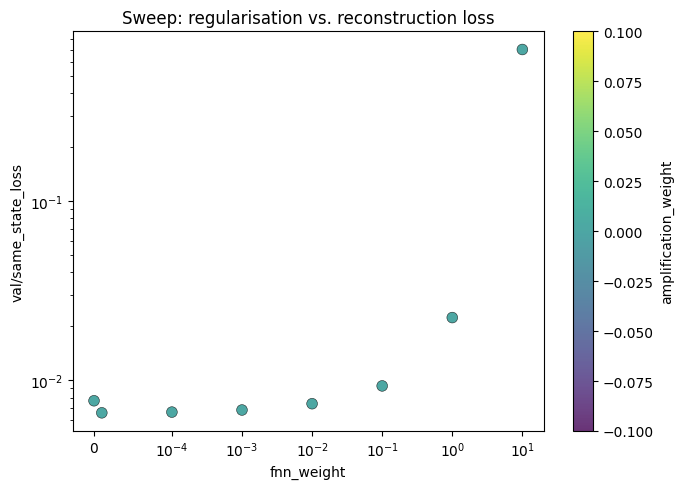

In [64]:
# ---- Scatter: fnn_weight vs val_same_state_loss, coloured by amplification_weight ----
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    df['fnn_weight'],
    df['val_same_loss'],
    c=df['amplification_weight'],
    cmap='viridis',
    s=60, alpha=0.8, edgecolors='k', linewidths=0.4,
)
plt.colorbar(sc, ax=ax, label='amplification_weight')
ax.set_xscale('symlog', linthresh=1e-4)
ax.set_yscale('log')
ax.set_xlabel('fnn_weight')
ax.set_ylabel('val/same_state_loss')
ax.set_title('Sweep: regularisation vs. reconstruction loss')
plt.tight_layout()
plt.show()

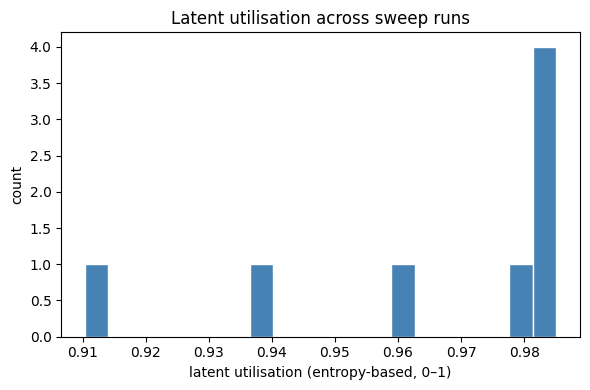

In [65]:
# ---- Latent utilisation distribution ----
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df['latent_util'].dropna(), bins=20, color='steelblue', edgecolor='white')
ax.set_xlabel('latent utilisation (entropy-based, 0\u20131)')
ax.set_ylabel('count')
ax.set_title('Latent utilisation across sweep runs')
plt.tight_layout()
plt.show()

In [66]:
# ---- Best run summary ----
best = df.iloc[0]
print('Best run (lowest val/same_state_loss):')
for col in df.columns:
    print(f'  {col:40s}: {best[col]}')

Best run (lowest val/same_state_loss):
  fnn_weight                              : 1e-05
  amplification_weight                    : 0
  decov_weight                            : 0
  val_same_loss                           : 0.006582798436284065
  val_next_loss                           : 0.011277555488049984
  val_fnn_loss                            : 0.49192318320274353
  val_amp_loss                            : nan
  latent_util                             : 0.9850628972053528
  val_total_loss                          : 0.017865272238850594
  run_name                                : WMTask__MLPSequenceEncoder__n_latent_128__same__next__fnn_weight_1e-05__run_0
  run_id                                  : ue9isr3e


## 8. Tangent Space Variance (Best Encoder)

Compute the variance explained by each dimension of the encoder tangent space for the best run (lowest val/same_state_loss), following the methodology from the Tangent Spaces notebook.

In [68]:
# -----------------------------------------------------------------------------
# Variance explained by each dimension of the encoder tangent space
# (Based on 2026-03-09 - Tangent Spaces.ipynb)
# -----------------------------------------------------------------------------
# Requires: df, best, trajs, WANDB_PROJECT_PATH, SAVE_DIR from Sections 3 and 7

from JacobianODE.encoder_only.pretrained import load_pretrained_encoder

# Load the best encoder (lowest val/same_state_loss)
adapter, _, _ = load_pretrained_encoder(
    project=WANDB_PROJECT_PATH,
    run_id=best["run_id"],
    save_dir=SAVE_DIR,
    freeze=True,
    verbose=True,
)
adapter.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
adapter.to(device)

# Training sequences: (n_sequences, seq_length, n_obs)
train_seq = trajs["train_trajs"].sequence.to(device)
n_obs = train_seq.shape[-1]
n_latent = adapter.n_latent


def encode_point(x):
    """Map single observation (D,) to latent (n_latent,)."""
    return adapter.encoder(x.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)


# Consecutive pairs for dz
x_t = train_seq[:, :-1, :].reshape(-1, n_obs)
print(f"x_t.shape: {x_t.shape}")
x_next = train_seq[:, 1:, :].reshape(-1, n_obs)
N_diff = min(16000, x_t.shape[0])
x_t = x_t[:N_diff]
x_next = x_next[:N_diff]
print(f"x_t.shape after reshape: {x_t.shape}, using {N_diff} consecutive pairs")
with torch.no_grad():
    z_t = adapter.encoder(x_t.unsqueeze(1)).squeeze(1)
    z_next = adapter.encoder(x_next.unsqueeze(1)).squeeze(1)
    dz = z_next - z_t
    print(f"dz.shape: {dz.shape}")
    jacobians_t = torch.func.vmap(torch.func.jacfwd(encode_point))(x_t)
    U, S, V = torch.linalg.svd(jacobians_t, full_matrices=True)

# Project dz onto local tangent basis U
tangent_projection = (dz.unsqueeze(1) @ U).squeeze(1)

# Variance explained per dimension
with torch.no_grad():
    squared_projections = tangent_projection**2
    variance_per_dim = squared_projections.mean(dim=0)
    total_variance = variance_per_dim.sum()
    variance_explained = variance_per_dim / total_variance
    cumulative_variance = torch.cumsum(variance_explained, dim=0)

print(f"\nTangent space variance (best encoder, fnn_weight={best.get('fnn_weight', 'N/A')}):")
print(f"{'Dimension':<10} | {'Variance Explained':<20} | {'Cumulative'}")
print("-" * 45)
for i in range(len(variance_explained)):
    val = variance_explained[i].item() * 100
    cum = cumulative_variance[i].item() * 100
    print(f"Dim {i+1:<5} | {val:>17.4f}% | {cum:>10.4f}%")

Loading checkpoint epoch=101-step=2346.ckpt...
x_t.shape: torch.Size([137616, 128])
x_t.shape after reshape: torch.Size([16000, 128]), using 16000 consecutive pairs
dz.shape: torch.Size([16000, 128])

Tangent space variance (best encoder, fnn_weight=1e-05):
Dimension  | Variance Explained   | Cumulative
---------------------------------------------
Dim 1     |            8.2096% |     8.2096%
Dim 2     |           19.1331% |    27.3428%
Dim 3     |           22.9318% |    50.2746%
Dim 4     |           21.0516% |    71.3262%
Dim 5     |           18.7023% |    90.0284%
Dim 6     |            8.8041% |    98.8325%
Dim 7     |            0.6990% |    99.5315%
Dim 8     |            0.2446% |    99.7761%
Dim 9     |            0.0411% |    99.8172%
Dim 10    |            0.0163% |    99.8335%
Dim 11    |            0.0168% |    99.8503%
Dim 12    |            0.0120% |    99.8623%
Dim 13    |            0.0087% |    99.8709%
Dim 14    |            0.0062% |    99.8771%
Dim 15    |        